In [1]:
# importacion de librerias
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import os
warnings.filterwarnings('ignore')


# Carga de los archivos .Csv

In [2]:
def cargar_csv(nombre_archivo):
    """
    Carga un archivo Csv de forma segura y dinámica.
    - nombre_archivo: str (ej. 'olist_customers_dataset.csv')

    """
    if not os.path.exists(nombre_archivo):
        print(f"❌ Error: El archivo '{nombre_archivo}' no se encuentra en la ruta especificada.")
        return None
        
    try:
        df = pd.read_csv(nombre_archivo)
        print(f"✅ ¡Éxito! Se cargó '{nombre_archivo}' con {df.shape[0]} filas y {df.shape[1]} columnas.")
        return df
    except Exception as e:
        print(f"❌ Ocurrió un error al leer el archivo: {e}")
        return None



In [3]:
# --- Uso de la funcion ---
df_customers = cargar_csv('olist_customers_dataset.csv')

✅ ¡Éxito! Se cargó 'olist_customers_dataset.csv' con 99441 filas y 5 columnas.


In [4]:
df_geolocation = cargar_csv('olist_geolocation_dataset.csv')

✅ ¡Éxito! Se cargó 'olist_geolocation_dataset.csv' con 1000163 filas y 5 columnas.


In [5]:
df_orders_items = cargar_csv('olist_order_items_dataset.csv')

✅ ¡Éxito! Se cargó 'olist_order_items_dataset.csv' con 112650 filas y 7 columnas.


In [6]:
df_order_payments = cargar_csv('olist_order_payments_dataset.csv')

✅ ¡Éxito! Se cargó 'olist_order_payments_dataset.csv' con 103886 filas y 5 columnas.


In [7]:
df_order_reviews = cargar_csv('olist_order_reviews_dataset.csv')

✅ ¡Éxito! Se cargó 'olist_order_reviews_dataset.csv' con 99224 filas y 7 columnas.


In [8]:
df_orders = cargar_csv('olist_orders_dataset.csv')

✅ ¡Éxito! Se cargó 'olist_orders_dataset.csv' con 99441 filas y 8 columnas.


In [9]:
df_products = cargar_csv('olist_products_dataset.csv')

✅ ¡Éxito! Se cargó 'olist_products_dataset.csv' con 32951 filas y 9 columnas.


In [10]:
df_sellers = cargar_csv('olist_sellers_dataset.csv')

✅ ¡Éxito! Se cargó 'olist_sellers_dataset.csv' con 3095 filas y 4 columnas.


In [11]:
df_category_name = cargar_csv('product_category_name_translation.csv')

✅ ¡Éxito! Se cargó 'product_category_name_translation.csv' con 71 filas y 2 columnas.


# Exploracion del archivo df_orders

In [12]:
# Tamaño del archivo
print('Tamaño del dataset:',df_orders.shape)

Tamaño del dataset: (99441, 8)


In [13]:
# Tipos de datos
print('Informacion del dataset df_orders:')
df_orders.info()

Informacion del dataset df_orders:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [14]:
# Valores Nulos en df_orders
df_orders.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [15]:
# Tratamiento de Nulos
print('Valores unicos de order_status:')
print(df_orders['order_status'].unique())

Valores unicos de order_status:
['delivered' 'invoiced' 'shipped' 'processing' 'unavailable' 'canceled'
 'created' 'approved']


In [16]:
# Cantidad de órdenes por estado
print(df_orders['order_status'].value_counts())

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


Conclusion de la exploracion del df_orders

* 96.478 órdenes entregadas — el 97% del dataset
* Los nulos en order_delivered_customer_date son las órdenes que no son delivered — tiene toda la lógica
* Las canceladas (625) y unavailable (609) también explican los nulos en fechas de entrega

Decisión para el EDA:
Para el análisis de revenue y performance vamos a trabajar solo con órdenes delivered — son las únicas que generaron ingreso real. Las demás las vamos a filtrar.

In [17]:
# Ordenes con estado delivered
df_orders_delivered = df_orders[df_orders['order_status'] == 'delivered'].copy()
df_orders_delivered.shape

(96478, 8)

# Corregir los tipos de datos
- Las columnas de fecha son del tipo Object, hay que convertirlas a datetime para poder hacer análisis temporales:
* order_purchase_timestamp	
* order_approved_at	
* order_delivered_carrier_date	
* order_delivered_customer_date
* order_estimated_delivery_date

In [18]:
df_orders_delivered['order_purchase_timestamp'] = pd.to_datetime(df_orders_delivered['order_purchase_timestamp'])

In [19]:
df_orders_delivered['order_approved_at'] = pd.to_datetime(df_orders_delivered['order_approved_at'])

In [20]:
df_orders_delivered['order_delivered_carrier_date'] = pd.to_datetime(df_orders_delivered['order_delivered_carrier_date'])

In [21]:
df_orders_delivered['order_delivered_customer_date'] = pd.to_datetime(df_orders_delivered['order_delivered_customer_date'])

In [22]:
df_orders_delivered['order_estimated_delivery_date'] = pd.to_datetime(df_orders_delivered['order_estimated_delivery_date'])

In [23]:
# Verificacion de la conversion de datos
df_orders_delivered.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96478 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       96478 non-null  object        
 1   customer_id                    96478 non-null  object        
 2   order_status                   96478 non-null  object        
 3   order_purchase_timestamp       96478 non-null  datetime64[ns]
 4   order_approved_at              96464 non-null  datetime64[ns]
 5   order_delivered_carrier_date   96476 non-null  datetime64[ns]
 6   order_delivered_customer_date  96470 non-null  datetime64[ns]
 7   order_estimated_delivery_date  96478 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.6+ MB


In [24]:
df_orders_delivered.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='object')

In [25]:
df_orders_items.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value'],
      dtype='object')

In [26]:
df_merged = pd.merge(
    df_orders_items,
    df_orders_delivered,
    on='order_id',
    how='inner'
)

In [27]:
df_merged.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17


In [28]:
df_merged.shape

(110197, 14)

In [29]:
# Agregamos la columna precio
df_merged['revenue'] = df_merged['price'] 

In [30]:
# Agregamos la columna freight
df_merged['freight'] = df_merged['freight_value']

In [31]:
# Agregamos la columna total
df_merged['total'] = df_merged['revenue'] + df_merged['freight']

In [32]:
df_merged.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,revenue,freight,total
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,199.90,18.14,218.04


# Primeras métricas globales

Números importantes del negocio a nivel global:

- Revenue total
- Ticket promedio por orden
- Cantidad de órdenes únicas

In [33]:
revenue_total = df_merged['total'].sum()
print('La facturacion total es:',revenue_total)

La facturacion total es: 15419773.75


In [34]:
ticket_promedio = df_merged.groupby('order_id')['total'].sum().mean()
print('El ticket promedio por orden es:',ticket_promedio)

El ticket promedio por orden es: 159.82683876116835


In [35]:
ordenes_unicas = df_merged['order_id'].nunique()
print('El total de ordenes unicas es:',ordenes_unicas)

El total de ordenes unicas es: 96478


* Revenue total: $15.4M
* Ticket promedio: $159.83
* Órdenes únicas: 96.478

# Analisis Temporal

In [36]:
# Agregamos las columnas year y month
df_merged['year'] = df_merged['order_purchase_timestamp'].dt.year
df_merged['month'] = df_merged['order_purchase_timestamp'].dt.month

In [37]:
# Verificacion de las columnas agregadas
df_merged.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,revenue,freight,total,year,month
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,58.90,13.29,72.19,2017,9
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,239.90,19.93,259.83,2017,4
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,199.00,17.87,216.87,2018,1
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,12.99,12.79,25.78,2018,8
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,199.90,18.14,218.04,2017,2


# Revenue por mes

In [38]:
revenue_por_mes = df_merged.groupby(['year', 'month'])['revenue'].sum()
print(revenue_por_mes)

year  month
2016  9           134.97
      10        40325.11
      12           10.90
2017  1        111798.36
      2        234223.40
      3        359198.85
      4        340669.68
      5        489338.25
      6        421923.37
      7        481604.52
      8        554699.70
      9        607399.67
      10       648247.65
      11       987765.37
      12       726033.19
2018  1        924645.00
      2        826437.13
      3        953356.25
      4        973534.09
      5        977544.69
      6        856077.86
      7        867953.46
      8        838576.64
Name: revenue, dtype: float64


* 2016 tiene solo 3 meses — el dataset arranca en septiembre
* Crecimiento sostenido durante 2017
* Noviembre 2017 es el pico más alto (~$987K) — probablemente Black Friday
* 2018 se estabiliza en torno a $900K mensuales

# Gráfico de evolución temporal

Para graficar necesitamos que el índice sea una fecha continua. Primero reseteamos el índice y creamos una columna de fecha combinando año y mes:

In [39]:
revenue_por_mes = revenue_por_mes.reset_index()
revenue_por_mes['fecha'] = pd.to_datetime(revenue_por_mes[['year', 'month']].assign(day=1))

In [40]:
revenue_por_mes.head()

,year,month,revenue,fecha
0,2016,9,134.97,2016-09-01
1,2016,10,40325.11,2016-10-01
2,2016,12,10.90,2016-12-01
3,2017,1,111798.36,2017-01-01
4,2017,2,234223.40,2017-02-01


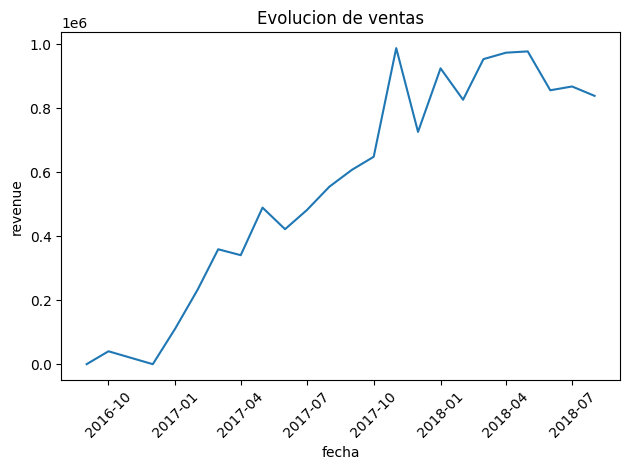

In [41]:
# Configuracion del Grafico
plt.plot(revenue_por_mes['fecha'], revenue_por_mes['revenue'])
plt.title('Evolucion de ventas')
plt.xlabel('fecha')
plt.ylabel('revenue')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Revenue por Categoría

In [42]:
df_merged = pd.merge(
    df_orders_items,
    df_orders_delivered,
    on='order_id',
    how='inner'
)

In [43]:
df_merged.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17


In [44]:
df_products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [45]:
df_category = pd.merge(
    df_merged,
    df_products,
    on='product_id',
    how='inner'
)

In [46]:
df_category.shape

(110197, 22)

Observacion:
El df_categoy mantiene las mismas 110.197 filas — eso significa que todos los productos tienen categoría asignada.
Problema: las categorías están en portugués. Por eso descargamos el archivo product_category_name_translation. Necesitamos un merge de df_category con df_category_name para agregar los nombres en inglés.

Buscamos la columna en comun en df_category y df_category_name para poder hacer el merge entre estas.

In [47]:
df_category.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value', 'customer_id',
       'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'product_category_name',
       'product_name_lenght', 'product_description_lenght',
       'product_photos_qty', 'product_weight_g', 'product_length_cm',
       'product_height_cm', 'product_width_cm'],
      dtype='object')

In [48]:
df_category_name.columns

Index(['product_category_name', 'product_category_name_english'], dtype='object')

In [49]:
df_full = pd.merge(
    df_category_name,
    df_category ,
    on='product_category_name',
    how='inner'
)

In [50]:
df_full.shape

(108638, 23)

In [51]:
df_full.head()

,product_category_name,product_category_name_english,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,customer_id,...,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,beleza_saude,health_beauty,0005a1a1728c9d785b8e2b08b904576c,1,310ae3c140ff94b03219ad0adc3c778f,a416b6a846a11724393025641d4edd5e,2018-03-26 18:31:29,145.95,11.65,16150771dfd4776261284213b89c304e,...,2018-03-28 00:37:42,2018-03-29 18:17:31,2018-03-29,59.0,493.0,1.0,2000.0,30.0,12.0,16.0
1,beleza_saude,health_beauty,00061f2a7bc09da83e415a52dc8a4af1,1,d63c1011f49d98b976c352955b1c4bea,cc419e0650a3c5ba77189a1882b7556a,2018-03-29 22:28:09,59.99,8.88,c6fc061d86fab1e2b2eac259bac71a49,...,2018-03-27 05:26:55,2018-03-29 00:04:19,2018-04-09,57.0,614.0,1.0,950.0,35.0,25.0,20.0
2,beleza_saude,health_beauty,001d8f0e34a38c37f7dba2a37d4eba8b,1,e67307ff0f15ade43fcb6e670be7a74c,f4aba7c0bca51484c30ab7bdc34bcdd1,2017-05-18 17:35:11,18.99,7.78,d987da9fb4086ab7c2c0f83963cd6722,...,2017-05-24 15:45:01,2017-05-26 13:14:50,2017-05-24,47.0,1474.0,3.0,150.0,43.0,13.0,14.0
3,beleza_saude,health_beauty,001d8f0e34a38c37f7dba2a37d4eba8b,2,e67307ff0f15ade43fcb6e670be7a74c,f4aba7c0bca51484c30ab7bdc34bcdd1,2017-05-18 17:35:11,18.99,7.78,d987da9fb4086ab7c2c0f83963cd6722,...,2017-05-24 15:45:01,2017-05-26 13:14:50,2017-05-24,47.0,1474.0,3.0,150.0,43.0,13.0,14.0
4,beleza_saude,health_beauty,001e7cf2ad6bef3ade12ebc56ceaf0f3,1,bdcf6a834e8faa30dac3886c7a58e92e,2a84855fd20af891be03bc5924d2b453,2018-05-22 10:59:50,35.90,15.20,d1684ed69f8fd574b7c344de923f379a,...,2018-05-21 14:34:00,2018-06-04 18:08:23,2018-06-05,26.0,394.0,1.0,1614.0,31.0,16.0,28.0


In [ ]:
# Agrego las columnas que faltan
df_full['revenue'] = df_full['price']
df_full['freight'] = df_full['freight_value']
df_full['total'] = df_full['revenue'] + df_full['freight']

* Top 10 categorías por revenue

In [53]:
top_category_revenue = df_full.groupby('product_category_name_english')['revenue'].sum().sort_values(ascending=False).head(10)
print(top_category_revenue)

product_category_name_english
health_beauty            1233131.72
watches_gifts            1166176.98
bed_bath_table           1023434.76
sports_leisure            954852.55
computers_accessories     888724.61
furniture_decor           711927.69
housewares                615628.69
cool_stuff                610204.10
auto                      578966.65
toys                      471286.48
Name: revenue, dtype: float64


Las 3 categorías con más revenue:

* Health & Beauty lidera con $1.23M
* Watches & Gifts segundo con $1.16M
* Bed, Bath & Table tercero con $1.02M

# Configuración del Gráfico Top 10 Categorías

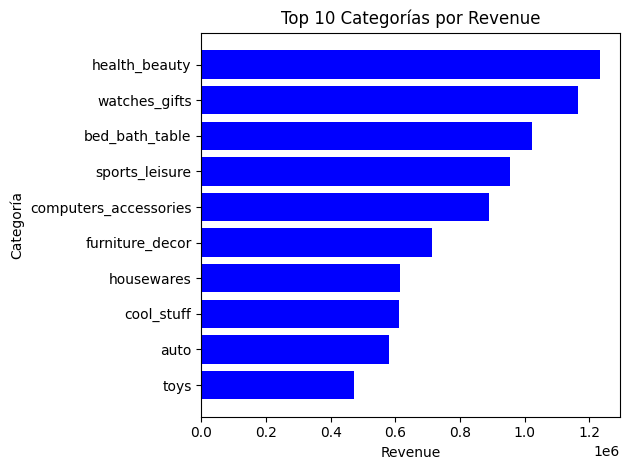

In [54]:
top_category_revenue = df_full.groupby('product_category_name_english')['revenue'].sum().sort_values(ascending=True).tail(10)

plt.barh(top_category_revenue.index, top_category_revenue.values, color='blue')
plt.title('Top 10 Categorías por Revenue')
plt.xlabel('Revenue')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()

# Analisis de Reviews

Buscamos la columna en comun entre df_full y df_order-reviews

In [55]:
df_full.columns

Index(['product_category_name', 'product_category_name_english', 'order_id',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'customer_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm', 'revenue',
       'freight', 'total'],
      dtype='object')

In [56]:
df_order_reviews.columns

Index(['review_id', 'order_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')

In [ ]:
# Merge de df_full con df_order_reviews
df_full_reviews = pd.merge(
    df_full,
    df_order_reviews ,
    on='order_id',
    how='inner'
)

In [58]:
df_full_reviews.shape

(108458, 32)

In [59]:
df_full_reviews.columns

Index(['product_category_name', 'product_category_name_english', 'order_id',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'customer_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm', 'revenue',
       'freight', 'total', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')

In [ ]:
#Valores unicos en review_score
df_full_reviews['review_score'].value_counts() 

review_score
5    62464
4    20879
1    12330
3     9144
2     3641
Name: count, dtype: int64

# Conclusión de las reviews


* 62.464 órdenes con score 5 — el 57% está muy satisfecho
* Score 1 es el tercero más frecuente — hay una polarización clara entre muy satisfechos e insatisfechos
* Scores 2 y 3 son los menos frecuentes

Esto es típico en e-commerce — la gente que deja review suele estar muy satisfecha o muy insatisfecha.

# Review score promedio por categoría

In [68]:
# Groupby por product_category_name_english y promedio de review_score.
top_reviews = df_full_reviews.groupby('product_category_name_english')['review_score'].mean().sort_values(ascending=False).head(10)
print('Review score promedio por categoría')
print(top_reviews)

Review score promedio por categoría
product_category_name_english
fashion_childrens_clothes                5.000000
cds_dvds_musicals                        4.642857
books_general_interest                   4.512195
books_imported                           4.508772
costruction_tools_tools                  4.444444
small_appliances_home_oven_and_coffee    4.438356
flowers                                  4.419355
books_technical                          4.393939
food_drink                               4.369004
fashion_sport                            4.366667
Name: review_score, dtype: float64


* fashion_childrens_clothes tiene 5.0 perfecto — pero probablemente tiene muy pocas órdenes, lo que hace que el promedio no sea representativo
* Libros y música dominan el top — categorías donde las expectativas son fáciles de cumplir
* Health & Beauty que lidera en revenue no aparece acá — interesante tensión entre volumen y satisfacción

In [69]:
# Verificamos cuántas órdenes tiene fashion_childrens_clothes — si son pocas, el 5.0 no es estadísticamente significativo:
df_full_reviews[df_full_reviews['product_category_name_english'] == 'fashion_childrens_clothes'].shape[0]

7

* La consulta nos devuelve solo 7 órdenes. Un promedio de 5.0 con 7 órdenes no es representativo estadísticamente. 
* Para hacer el análisis más honesto, filtramos las categorías que tengan al menos 100 órdenes antes de calcular el promedio. 

In [70]:
top_reviews = df_full_reviews.groupby('product_category_name_english').filter(lambda x: len(x) >= 100).groupby('product_category_name_english')['review_score'].mean().sort_values(ascending=False).head(10)
print(top_reviews)

product_category_name_english
books_general_interest    4.512195
books_technical           4.393939
food_drink                4.369004
luggage_accessories       4.352283
fashion_shoes             4.285156
food                      4.262834
furniture_bedroom         4.252427
stationery                4.244002
home_appliances           4.225602
small_appliances          4.225266
Name: review_score, dtype: float64


# El resultado ahora sí tiene sentido:

* Libros siguen liderando — expectativas claras y fáciles de cumplir
* Food & Drink aparece — productos que generan satisfacción alta
* Health & Beauty sigue sin aparecer en el top de satisfacción, pero lidera en revenue

# Configuración del Gráfico Review score por categoría

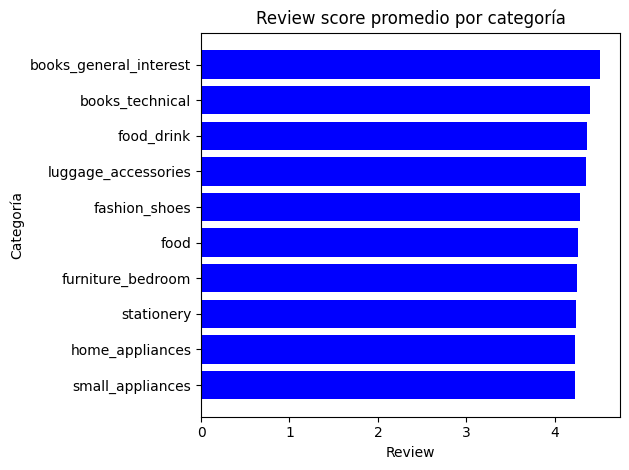

In [ ]:
top_reviews = df_full_reviews.groupby('product_category_name_english').filter(lambda x: len(x) >= 100).groupby('product_category_name_english')['review_score'].mean().sort_values(ascending=True).tail(10)
plt.barh(top_reviews.index, top_reviews.values, color='blue')
plt.title('Review score promedio por categoría')
plt.xlabel('Review')
plt.ylabel('Categoría')
plt.tight_layout()
plt.show()

# Análisis de métodos de pago

* Incorporamos df_order_payments al análisis.
* Buscamos la columna en común de df_full_reviews con df_order_payments para hacer un merge

In [73]:
df_full_reviews.columns

Index(['product_category_name', 'product_category_name_english', 'order_id',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'customer_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm', 'revenue',
       'freight', 'total', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp'],
      dtype='object')

In [74]:
df_order_payments.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

In [75]:
# Merge de df_full_reviews con df_order_payments
df_payments = pd.merge(
    df_full_reviews,
    df_order_payments ,
    on='order_id',
    how='inner'
)

In [76]:
df_payments.shape

(113210, 36)

In [77]:
#Valores unicos en payment_type
df_payments['payment_type'].value_counts() 

payment_type
credit_card    83536
boleto         22029
voucher         6022
debit_card      1623
Name: count, dtype: int64

* Credit card domina ampliamente con el 74% de los pagos, seguido de boleto (un método de pago muy popular en Brasil, equivale a un cupón de pago en efectivo).

# Revenue por método de pago

In [ ]:
# Groupby por payment_type y suma de revenue, ordenado de mayor a menor. 
revenue_payments = df_payments.groupby('payment_type')['revenue'].sum().sort_values(ascending=False)
print('revenue por metodo de pago')
print(revenue_payments)

revenue por metodo de pago
payment_type
credit_card    10495076.53
boleto          2284858.89
voucher          615287.77
debit_card       174915.16
Name: revenue, dtype: float64


* Credit card genera el 77% del revenue total.

# Configuración del Gráfico Revenue por método de pago

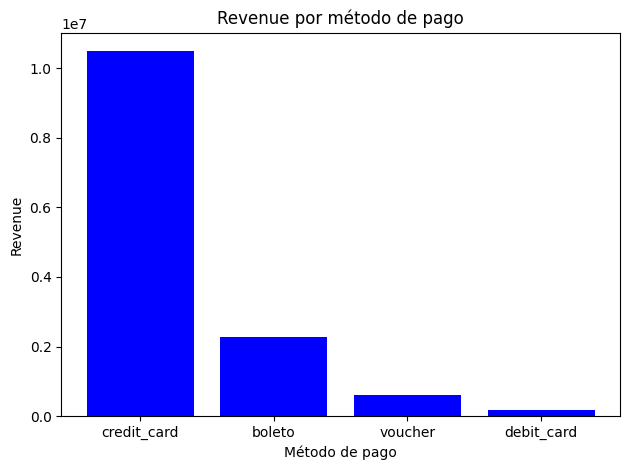

In [84]:
plt.bar(revenue_payments.index, revenue_payments.values, color='blue')
plt.title('Revenue por método de pago')
plt.xlabel('Método de pago')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

# Análisis de Cuotas

In [90]:
promedio_cuotas = df_payments[df_payments['payment_type'] == 'credit_card']['payment_installments'].mean()
print('Promedio de cuotas en tarjeta de crédito:', promedio_cuotas)

Promedio de cuotas en tarjeta de crédito: 3.6338823980080446


* En promedio los clientes pagan en 3.6 cuotas con tarjeta de crédito. Típico comportamiento de e-commerce en Brasil donde el crédito en cuotas es muy común culturalmente.

# Análisis geográfico

* Incorporamos df_customers que tiene el estado (customer_state) de cada cliente.
* Buscamos la columna en común entre df_payments y df_customers para hacer el merge. 


In [91]:
df_payments.columns

Index(['product_category_name', 'product_category_name_english', 'order_id',
       'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date',
       'price', 'freight_value', 'customer_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm', 'revenue',
       'freight', 'total', 'review_id', 'review_score', 'review_comment_title',
       'review_comment_message', 'review_creation_date',
       'review_answer_timestamp', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value'],
      dtype='object')

In [92]:
df_customers.columns

Index(['customer_id', 'customer_unique_id', 'customer_zip_code_prefix',
       'customer_city', 'customer_state'],
      dtype='object')

In [93]:
# Merge de df_payments con df_customers
df_geo = pd.merge(
    df_payments,
    df_customers ,
    on='customer_id',
    how='inner'
)

In [94]:
df_geo.shape

(113210, 40)

In [ ]:
# Revenue por estado

df_geo['customer_state'].value_counts()

In [96]:
# Groupby por payment_type y suma de revenue, ordenado de mayor a menor. 
revenue_state = df_geo.groupby('customer_state')['revenue'].sum().sort_values(ascending=False)
print('revenue por estado')
print(revenue_state)

revenue por estado
customer_state
SP    5236620.38
RJ    1802929.41
MG    1578781.29
RS     757860.27
PR     681234.79
BA     511455.97
SC     508697.72
DF     305283.47
GO     288845.61
ES     265029.91
PE     253283.41
CE     228599.06
PA     167246.79
MT     153886.30
MS     119100.04
MA     118092.29
PB     115365.05
RN      92445.03
PI      88306.87
AL      79833.46
SE      57499.42
TO      54529.79
RO      45898.59
AM      22052.47
AC      16940.56
AP      13508.91
RR       6811.49
Name: revenue, dtype: float64


São Paulo domina ampliamente con $5.2M — casi el triple que Rio de Janeiro, en segundo lugar. Tiene sentido, SP es el centro económico de Brasil.

# Configuración del Gráfico Top 10 Revenue por Estado

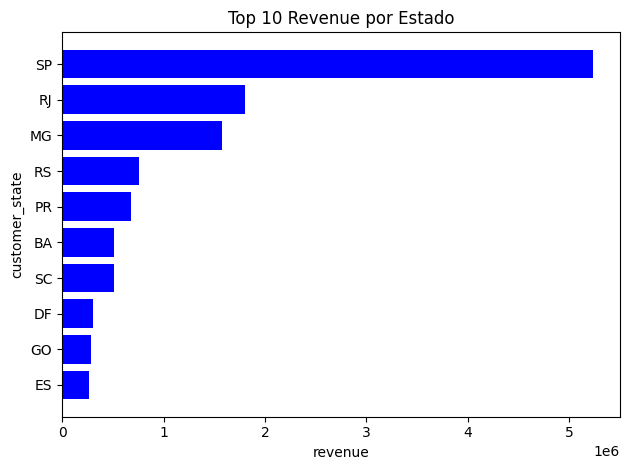

In [97]:
revenue_state = df_geo.groupby('customer_state')['revenue'].sum().sort_values(ascending=True).tail(10)
plt.barh(revenue_state.index, revenue_state.values, color='blue')
plt.title('Top 10 Revenue por Estado')
plt.xlabel('revenue')
plt.ylabel('customer_state')
plt.tight_layout()
plt.show()

## 📊 Conclusiones del EDA

### Métricas globales
- Revenue total: $15.4M en el período 2016-2018
- Ticket promedio por orden: $159.83
- Total de órdenes entregadas: 96.478

### Evolución temporal
- Crecimiento sostenido durante 2017
- Pico máximo en Noviembre 2017 (~$987K) — probable impacto de Black Friday
- 2018 se estabiliza en torno a $900K mensuales

### Categorías
- Health & Beauty lidera en revenue ($1.23M) pero no aparece en el top de satisfacción
- Books y Food & Drink tienen los mejores scores de satisfacción promedio
- Existe una tensión entre volumen de ventas y satisfacción del cliente

### Métodos de pago
- Credit card representa el 77% del revenue total
- Promedio de 3.6 cuotas en pagos con tarjeta — comportamiento típico del mercado brasileño

### Geografía
- São Paulo concentra el 34% del revenue total ($5.2M)
- Los 3 estados principales (SP, RJ, MG) representan más del 56% del revenue

# Exportamos df_geo como CSV para usar en la Etapa 2 (MySQL)

In [98]:
df_geo.to_csv('df_full_olist.csv', index=False)

El EDA está completo. 

Resumen de lo construido:

- ✅ Carga y exploración de 9 datasets
- ✅ Limpieza y filtrado de datos
- ✅ 5 merges entre tablas
- ✅ Métricas globales de negocio
- ✅ 5 análisis con visualizaciones
- ✅ Conclusiones documentadas
- ✅ Export del dataset consolidado